In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import elementary_charge as q

# Define file paths
datadir = Path(
    '/home/mike/Shares/Shredder/Research Projects/UVDCS/Data/6-15-2026/Noise Scaling RFSA')
datafile = datadir / 'NoiseScaling.ods'
spectradir = datadir / 'Spectra'

# RFSA Config
rbw = 300e3

# Integration center/range
rf_center_freq = 25e6
bandwidth = 20e6

# Detector values
trans_gain = 10e3
output_imp = 50
photon_mult = 10 * 156/42


def load_file(head):
    filename = spectradir / head
    filename = filename.with_suffix('.csv')
    return pd.read_csv(filename, skiprows=34, nrows=785-34, names=['Frequency (Hz)', 'RF Power (dBm)'])


def integrate_noise(df):
    rf_mask = (df['Frequency (Hz)'] < rf_center_freq + bandwidth /
               2) & (df['Frequency (Hz)'] > rf_center_freq - bandwidth / 2)
    noise_band_log = df['RF Power (dBm)'][rf_mask]
    noise_band_lin = 10**(noise_band_log/10) / 1000  # Watts
    noise_psd_mean = np.mean(noise_band_lin)/rbw # W/Hz
    return noise_psd_mean


def linear(x, m, b):
    return m * x + b


# Construct dataframe
data = pd.read_excel(datafile)
background_data = data.tail(2)
data = data.iloc[:-2]


# Load files and integrate noise
data['RF Spectrum'] = data['RFSA File Name'].apply(load_file)
data['PSD (W/Hz)'] = data['RF Spectrum'].apply(integrate_noise)
data['DC Voltage (V)'] = data['DC Voltage (mV)'] * 1e-3

test_spectrum = data.iloc[5]['RF Spectrum']
plt.plot(test_spectrum['Frequency (Hz)'], test_spectrum['RF Power (dBm)'])
plt.vlines([rf_center_freq - bandwidth/2, rf_center_freq +
           bandwidth/2], [-100, -100], [0, 0], 'k')
plt.show()

xaxis = 'DC Voltage (V)'
yaxis = 'PSD (W/Hz)'

x = data[xaxis].to_numpy()
y = data[yaxis].to_numpy()

# Linear fit with intercept fixed at 0
popt, _ = curve_fit(linear, x, y)


# Plot fit
x_fit = np.linspace(0, x.max(), 1000)
y_fit = linear(x_fit, *popt)

excess_noise = popt[0] * output_imp / 2 / trans_gain / q / photon_mult
print(f'Excess noise: {excess_noise}')

plt.scatter(x, y, label='Data')
plt.plot(x_fit, y_fit, 'r', label=f'Linear Fit')
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.grid()
plt.legend()
plt.savefig('noise_scaling.png', bbox_inches='tight')
plt.show()


# VSA Plot

    DC Voltage (mV)              File Name  \
13             -0.6    detector_background   
14              NaN  instrument_background   

                                          RF Spectrum  
13        Frequency (Hz)  Voltage Noise (Vrms/rtHz...  
14        Frequency (Hz)  Voltage Noise (Vrms/rtHz...  


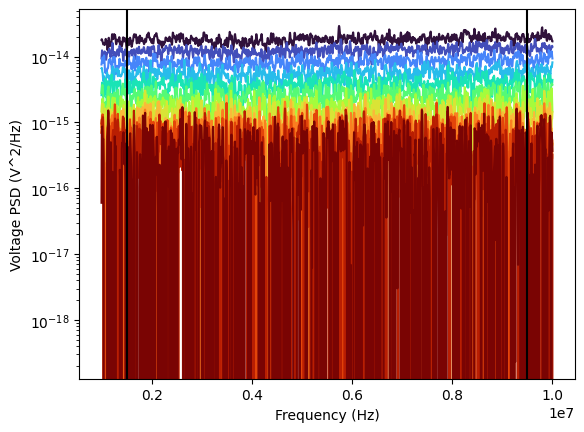

Excess noise: 4.648773550862472
k=0.08413933176401368


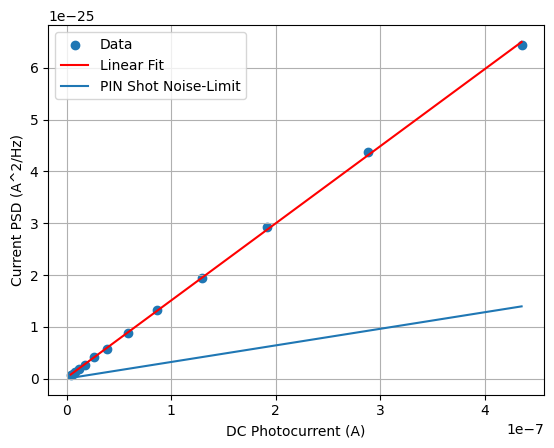

In [70]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import elementary_charge as q
from scipy.optimize import fsolve

# Define file paths
datadir = Path(
    r'Z:\Research Projects\UVDCS\Data\6-23-2026\Noise Scaling VSA')
datafile = datadir / 'NoiseScaling.ods'
spectradir = datadir / 'Spectra'

# Integration center/range
rf_center_freq = 5.5e6
bandwidth = 8e6

# Detector values
trans_gain_dc = 10e3
trans_gain_50 = 5e3

output_imp = 50
photon_mult = 10 * 144/42.6


def load_file(head):
    filename = spectradir / head
    filename = filename.with_suffix('.txt')
    return pd.read_csv(filename, names=['Frequency (Hz)', 'Voltage Noise (Vrms/rtHz)'], delimiter=' ')


def integrate_noise(df):
    rf_mask = (df['Frequency (Hz)'] < rf_center_freq + bandwidth /
               2) & (df['Frequency (Hz)'] > rf_center_freq - bandwidth / 2)
    # noise_band_lin = df['Voltage Noise (Vrms/rtHz)'][rf_mask]
    noise_band_lin = df['Voltage PSD (V^2/Hz)'][rf_mask]
    noise_psd_mean = np.mean(noise_band_lin) # Vrms/rtHz
    return noise_psd_mean

def subtract_background(df, background):
    df = df.copy()
    df['Voltage PSD (V^2/Hz)'] = df['Voltage Noise (Vrms/rtHz)']**2 - background['Voltage Noise (Vrms/rtHz)']**2
    # df['Voltage Noise (Vrms/rtHz)'] -= background['Voltage Noise (Vrms/rtHz)']
    return df

def linear(x, m, b):
    return m * x + b


# Construct dataframe
data = pd.read_excel(datafile)
background_data = data.tail(2)
data = data.iloc[:-2]


# Load files and integrate noise
data['RF Spectrum'] = data['File Name'].apply(load_file)
background_data['RF Spectrum'] = background_data['File Name'].apply(load_file)
print(background_data)

background_spectrum = background_data.loc[background_data['File Name']=='detector_background']['RF Spectrum'].iloc[0]

# Subtract detector background
data['RF Spectrum'] = data['RF Spectrum'].apply(
    lambda df: subtract_background(df, background_spectrum)
)
# data['Current PSD (A^2/Hz)'] = (data['RF Spectrum'].apply(integrate_noise) ) ** 2 / trans_gain_50**2 / photon_mult**2 
data['Current PSD (A^2/Hz)'] = (data['RF Spectrum'].apply(integrate_noise) ) / trans_gain_50**2 / photon_mult**2 

data['DC Voltage (V)'] = data['DC Voltage (mV)'] * 1e-3 - background_data.loc[background_data['File Name']=='detector_background']['DC Voltage (mV)'].iloc[0] * 1e-3
data['DC Photocurrent (A)'] = data['DC Voltage (V)'] / trans_gain_dc / photon_mult 

fig, ax = plt.subplots()
xaxis='Frequency (Hz)'
yaxis='Voltage PSD (V^2/Hz)'
colors = plt.cm.turbo(np.linspace(0, 1, len(data)))
ax.set_prop_cycle(color=colors)

for i, row in data.iterrows():
    spectrum = row['RF Spectrum']
    plt.semilogy(spectrum[xaxis], spectrum[yaxis])

plt.vlines([rf_center_freq - bandwidth/2, rf_center_freq +
           bandwidth/2], [0,0], [1e-6, 1e-6], 'k')
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.show()

xaxis = 'DC Photocurrent (A)'
yaxis = 'Current PSD (A^2/Hz)'

x = data[xaxis].to_numpy()
y = data[yaxis].to_numpy()

# Linear fit 
popt, _ = curve_fit(linear, x, y)


# Plot fit
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = linear(x_fit, *popt)

excess_noise = popt[0]  / 2 / q 
def excess_noise_equation(k, F=2, M=1):
    return F - (k * M + (1-k) * (2-1/M))
    
print(f'Excess noise: {excess_noise}')
ionization_ratio = fsolve(excess_noise_equation, x0=.02, args=(excess_noise, photon_mult))
print(f'k={ionization_ratio[0]}')
# xerr = .1e-3/trans_gain_dc
# xerr_array = len(x) * [xerr]
# print(xerr)
plt.scatter(x, y,label='Data')
# plt.errorbar(x, y, xerr=xerr_array, fmt='none')
plt.plot(x_fit, y_fit, 'r', label=f'Linear Fit')
plt.plot(x_fit, 2*q*x_fit, label='PIN Shot Noise-Limit')
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.grid()
plt.legend()
plt.savefig('noise_scaling.png', bbox_inches='tight')
plt.show()


# "Clearance Ratio"

    DC Voltage (mV)              File Name  \
13             -0.6    detector_background   
14              NaN  instrument_background   

                                          RF Spectrum  
13        Frequency (Hz)  Voltage Noise (Vrms/rtHz...  
14        Frequency (Hz)  Voltage Noise (Vrms/rtHz...  


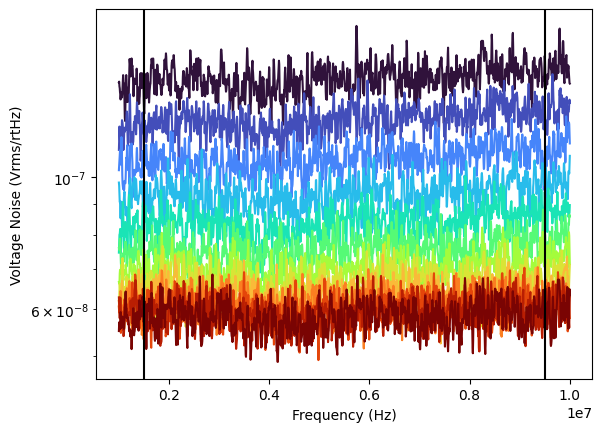

Excess noise: 1.1716618413467297e+25
k=0.02


C:\Users\Splinter-User\AppData\Local\Temp\ipykernel_18164\841630728.py:107: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  ionization_ratio = fsolve(excess_noise_equation, x0=.02, args=(excess_noise, photon_mult))


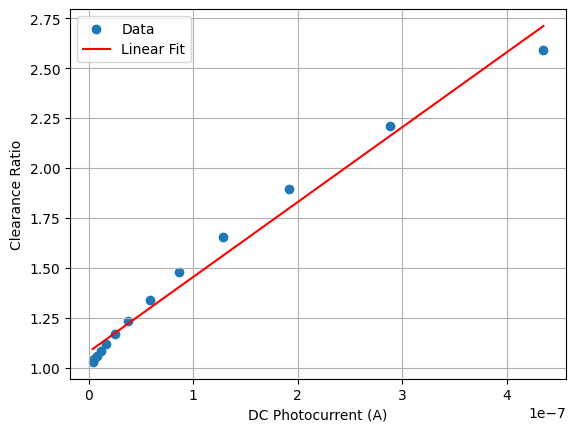

In [63]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import elementary_charge as q
from scipy.optimize import fsolve

# Define file paths
datadir = Path(
    r'Z:\Research Projects\UVDCS\Data\6-23-2026\Noise Scaling VSA')
datafile = datadir / 'NoiseScaling.ods'
spectradir = datadir / 'Spectra'

# Integration center/range
rf_center_freq = 5.5e6
bandwidth = 8e6

# Detector values
trans_gain_dc = 10e3
trans_gain_50 = 5e3

output_imp = 50
photon_mult = 10 * 144/42.6


def load_file(head):
    filename = spectradir / head
    filename = filename.with_suffix('.txt')
    return pd.read_csv(filename, names=['Frequency (Hz)', 'Voltage Noise (Vrms/rtHz)'], delimiter=' ')


def integrate_noise(df):
    rf_mask = (df['Frequency (Hz)'] < rf_center_freq + bandwidth /
               2) & (df['Frequency (Hz)'] > rf_center_freq - bandwidth / 2)
    noise_band_lin = df['Voltage Noise (Vrms/rtHz)'][rf_mask]
    noise_psd_mean = np.mean(noise_band_lin) # Vrms/rtHz
    return noise_psd_mean

def divide_background(df, background):
    df = df.copy()
    df['Voltage Noise (Vrms/rtHz)'] /= background['Voltage Noise (Vrms/rtHz)']
    return df

def linear(x, m, b):
    return m * x + b


# Construct dataframe
data = pd.read_excel(datafile)
background_data = data.tail(2)
data = data.iloc[:-2]


# Load files and integrate noise
data['RF Spectrum'] = data['File Name'].apply(load_file)
background_data['RF Spectrum'] = background_data['File Name'].apply(load_file)
print(background_data)

background_spectrum = background_data.loc[background_data['File Name']=='detector_background']['RF Spectrum'].iloc[0]

# Divide detector background
data['Clearance Ratio'] = data['RF Spectrum'].apply(
    lambda df: divide_background(df, background_spectrum)
)

data['Clearance Ratio'] = (data['Clearance Ratio'].apply(integrate_noise) ) 

data['DC Voltage (V)'] = data['DC Voltage (mV)'] * 1e-3 - background_data.loc[background_data['File Name']=='detector_background']['DC Voltage (mV)'].iloc[0] * 1e-3
data['DC Photocurrent (A)'] = data['DC Voltage (V)'] / trans_gain_dc / photon_mult 

fig, ax = plt.subplots()
xaxis='Frequency (Hz)'
yaxis='Voltage Noise (Vrms/rtHz)'
colors = plt.cm.turbo(np.linspace(0, 1, len(data)))
ax.set_prop_cycle(color=colors)

for i, row in data.iterrows():
    spectrum = row['RF Spectrum']
    plt.semilogy(spectrum[xaxis], spectrum[yaxis])

plt.vlines([rf_center_freq - bandwidth/2, rf_center_freq +
           bandwidth/2], [0,0], [1e-6, 1e-6], 'k')
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.show()

xaxis = 'DC Photocurrent (A)'
yaxis = 'Clearance Ratio'

x = data[xaxis].to_numpy()
y = data[yaxis].to_numpy()

# Linear fit 
popt, _ = curve_fit(linear, x, y)


# Plot fit
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = linear(x_fit, *popt)

excess_noise = popt[0]  / 2 / q 
def excess_noise_equation(k, F=2, M=1):
    return F - (k * M + (1-k) * (2-1/M))
    
print(f'Excess noise: {excess_noise}')
ionization_ratio = fsolve(excess_noise_equation, x0=.02, args=(excess_noise, photon_mult))
print(f'k={ionization_ratio[0]}')
# xerr = .1e-3/trans_gain_dc
# xerr_array = len(x) * [xerr]
# print(xerr)
plt.scatter(x, y,label='Data')
# plt.errorbar(x, y, xerr=xerr_array, fmt='none')
plt.plot(x_fit, y_fit, 'r', label=f'Linear Fit')
# plt.plot(x_fit, 2*q*x_fit, label='PIN Shot Noise-Limit')
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.grid()
plt.legend()
plt.savefig('noise_scaling.png', bbox_inches='tight')
plt.show()
